In [1]:
import jaxdem as jd
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
state = jd.utils.h5.load('state.h5')
system = jd.utils.h5.load('system.h5')
state_traj = jd.utils.h5.load('state_traj.h5')
system_traj = jd.utils.h5.load('system_traj.h5')

pe = jax.vmap(jax.vmap(jd.utils.thermal.compute_potential_energy))(state_traj, system_traj)
ke = jax.vmap(jax.vmap(jd.utils.thermal.compute_translational_kinetic_energy))(state_traj)

W0202 18:06:58.720122 2240340 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.
W0202 18:06:58.722136 2238069 cuda_executor.cc:1802] GPU interconnect information not available: INTERNAL: NVML doesn't support extracting fabric info or NVLink is not used by the device.


In [3]:
from anim import render
for i, (st, sy) in enumerate(zip(
    jd.State.unstack(state),
    jd.System.unstack(system)
)):
    render(st, sy, f'run-{i}.png')

Running preprocessing on config.h5...
Metadata: 2 13.907163560824488 13.907163560824488
Running rendering -> run-0.png...
Headless Linux detected (DISPLAY unset). Using xvfb-run.
Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified
Saved rendering to run-0.png
Success.
Running preprocessing on config.h5...
Metadata: 2 13.907163560824488 13.907163560824488
Running rendering -> run-1.png...
Headless Linux detected (DISPLAY unset). Using xvfb-run.
Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified
Authorization required, but no authorization protocol specified
Saved rendering to run-1.png
Success.
Running preprocessing on config.h5...
Metadata: 2 13.907163560824488 13.907163560824488
Running rendering -> run-2.png...
Headless Linux detected (DISPLAY unset). Using xvfb-run.
Aut

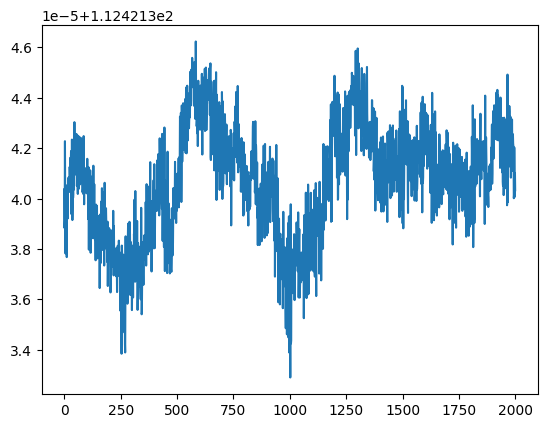

In [8]:
# plt.plot((pe + ke)[:, 0])
# plt.plot((pe + ke)[:, 1])
# plt.plot((pe + ke)[:, 2])
# plt.plot((pe + ke)[:, 3])
plt.plot((pe + ke)[:, 4])

In [9]:
i = 0
N = 100
import numpy as np
pos = np.array(state_traj.pos[:N, i])
rad = np.array(state_traj.rad[:N, i])
did = np.array(state_traj.unique_ID[:N, i])
box_size = np.array(system_traj.domain.box_size[:N, i])

import subprocess
from pathlib import Path
import h5py
with h5py.File("traj.h5", "w") as f:
    f.create_dataset("pos", data=pos)
    f.create_dataset("rad", data=rad)
    f.create_dataset("ID", data=did)
    f.create_dataset("box_size", data=box_size)

# --- Optional: generate a GIF animation (requires ParaView pvbatch) ---
run_animation = "/home/mmccraw/dev/analysis/fall-25/12/testing-jaxdem-scripts/animation/run_animation.sh"
# run_animation = "/Users/marshallmccraw/Projects/yale/analysis/fall-25/12/testing-jaxdem-scripts/animation/run_animation.sh"
subprocess.run(
    [
        str(run_animation),
        "traj.h5",
        'test.gif',
        str(100),   # num_frames (evenly sampled if traj has more)
        "1000",  # base_pixels
        str(15),    # fps
    ],
    check=True,
)

Preprocess: 100%|██████████| 100/100 [00:00<00:00, 1422.56it/s]


Saved GIF to test.gif


CompletedProcess(args=['/home/mmccraw/dev/analysis/fall-25/12/testing-jaxdem-scripts/animation/run_animation.sh', 'traj.h5', 'test.gif', '100', '1000', '15'], returncode=0)

Measure energy conservation in wca